[ WARN:0@113.774] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
ioctl(VIDIOC_QBUF): Bad file descriptor
[ WARN:0@114.935] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video3): can't open camera by index
ioctl(VIDIOC_QBUF): Bad file descriptor


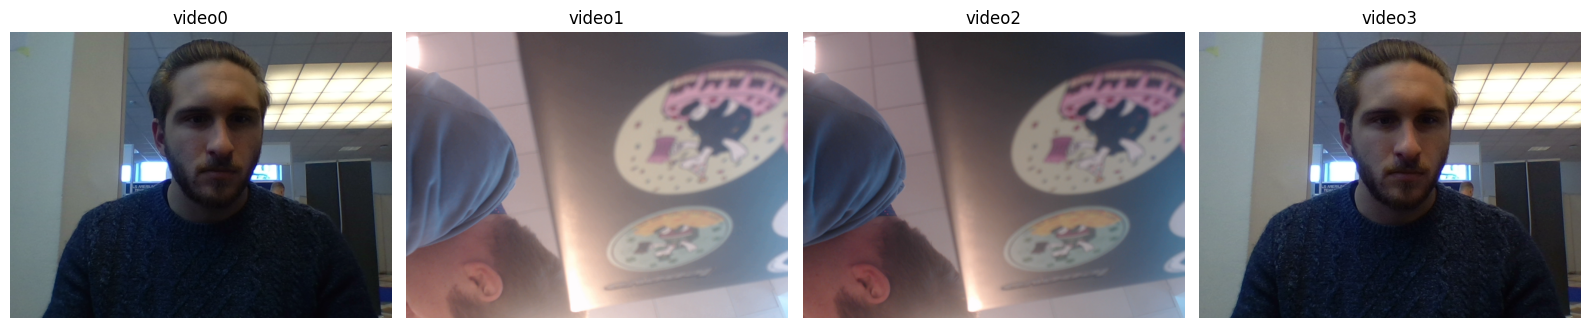

In [4]:
import cv2
import matplotlib.pyplot as plt
import os

# Show a preview from each video device so you can identify the Logitech
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx in range(4):
    cap = cv2.VideoCapture(idx)
    if cap.isOpened():
        for _ in range(3):
            cap.read()
        ret, frame = cap.read()
        cap.release()
        if ret:
            axes[idx].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            axes[idx].set_title(f"video{idx}")
            axes[idx].axis("off")
            continue
    axes[idx].set_title(f"video{idx} — n/a")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [39]:
from datetime import datetime
CAMERA_INDEX = 2

cap = cv2.VideoCapture(CAMERA_INDEX)
if not cap.isOpened():
    raise RuntimeError(f"Could not open /dev/video{CAMERA_INDEX}")

for _ in range(30):
    cap.read()

ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Failed to capture frame")

os.makedirs("data", exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
save_path = f"../data/motor_{ts}.png"
cv2.imwrite(save_path, frame)
print(f"Saved to {save_path}")

rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 7))
plt.imshow(rgb)
plt.axis("off")
plt.title(save_path)
plt.show()

Saved to ../data/motor_20260331_102829.png


In [20]:
%matplotlib tk
import cv2, json, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

IMAGE_PATH = "../data/motor_logi.png"

# Labels to cycle through — edit as needed
LABELS = ["motor_center", "extension", "hole", "other"]
COLORS = ["red", "lime", "cyan", "yellow"]

img = cv2.cvtColor(cv2.imread(IMAGE_PATH), cv2.COLOR_BGR2RGB)
annotations = []  # list of {label, x, y}
current_label = [0]  # mutable so closure can modify it

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)
ax.set_title(f"Click to annotate  |  Current label: [{LABELS[0]}]  |  Right-click to undo  |  Close window to save")

# Legend
patches = [mpatches.Patch(color=COLORS[i], label=LABELS[i]) for i in range(len(LABELS))]
ax.legend(handles=patches, loc="upper right")

status = ax.text(10, 20, f"Label: {LABELS[0]}", color="white",
                 fontsize=12, backgroundcolor="black")

def on_click(event):
    if event.inaxes != ax or event.xdata is None:
        return
    if event.button == 1:  # left click — place point
        lbl = LABELS[current_label[0]]
        col = COLORS[current_label[0]]
        x, y = int(event.xdata), int(event.ydata)
        annotations.append({"label": lbl, "x": x, "y": y})
        ax.plot(x, y, "o", color=col, markersize=10)
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(6, 6),
                    color=col, fontsize=9, fontweight="bold")
        fig.canvas.draw()
    elif event.button == 3:  # right click — undo last
        if annotations:
            annotations.pop()
            ax.cla()
            ax.imshow(img)
            ax.legend(handles=patches, loc="upper right")
            for a in annotations:
                i = LABELS.index(a["label"])
                ax.plot(a["x"], a["y"], "o", color=COLORS[i], markersize=10)
                ax.annotate(a["label"], (a["x"], a["y"]),
                            textcoords="offset points", xytext=(6, 6),
                            color=COLORS[i], fontsize=9, fontweight="bold")
            fig.canvas.draw()

def on_key(event):
    if event.key in [str(i+1) for i in range(len(LABELS))]:
        current_label[0] = int(event.key) - 1
        lbl = LABELS[current_label[0]]
        ax.set_title(f"Click to annotate  |  Current label: [{lbl}]  |  Right-click to undo  |  Close window to save")
        fig.canvas.draw()

def on_close(event):
    save_path = "../data/annotations.json"
    with open(save_path, "w") as f:
        json.dump(annotations, f, indent=2)
    print(f"Saved {len(annotations)} annotations to {save_path}")
    for a in annotations:
        print(f"  {a['label']:20s}  x={a['x']:4d}  y={a['y']:4d}")

fig.canvas.mpl_connect("button_press_event", on_click)
fig.canvas.mpl_connect("key_press_event", on_key)
fig.canvas.mpl_connect("close_event", on_close)

print("Keys 1-4 switch label:  1=motor_center  2=extension  3=hole  4=other")
print("Left click = place point,  Right click = undo last")
plt.tight_layout()
plt.show()

Keys 1-4 switch label:  1=motor_center  2=extension  3=hole  4=other
Left click = place point,  Right click = undo last
